## analysing enso characteristics and its changes in access stabilised runs

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
import matplotlib as mpl
import matplotlib.ticker as mticker
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [3]:
import cmocean

In [4]:
from scipy import stats

In [ ]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 14
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 0.8
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [ ]:
def plot_decorator():
    ax = plt.gca()
    
    # Minor ticks
    # ax.minorticks_on()
    # plt.tick_params(which='minor', axis='x', bottom=False)
    
    # Grid (light, behind data)
    ax.grid(color='gray', lw=0.4, alpha=0.1)
    
    # Remove top/right spines (Nature style)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Tight layout
    # plt.tight_layout()

In [ ]:
### Functions needed for the analysis

In [ ]:
import matplotlib as m
from matplotlib.colors import BoundaryNorm as BM
from matplotlib.colors import LogNorm as LM
import matplotlib.patches as mpatches

In [ ]:
def plot_background(ax):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    # ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=True,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 14, 'color': 'k'}
    gl.ylabel_style = {'size': 14, 'color': 'k'}
    return ax


def plot_maps(x, y, z, titles, labels, cmap, levels, cbar_label = 'Precip', pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False, add_patch_extra=False, cbar_orientation='vertical', hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160)):
    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=True, subplot_kw={'projection':proj})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        plot_background(ax)
        # ax.set_aspect('auto')
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        axlist[i].set_title(titles[i], fontsize=16)
        if draw_winds:
            axlist[i].quiver(x[::3, ::3], y[::3, ::3], u_wnd[i].to_numpy()[::3, ::3], v_wnd[i].to_numpy()[::3, ::3], scale=wind_scale, color='k', transform=ccrs.PlateCarree())
        if draw_contour:
            axlist[i].contour(x, y, contour_data[i], cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0))
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            if hatch_type == 'insig':
                pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
            elif hatch_type == 'sig':
                pval_plot = np.ma.masked_greater(pval[i], 0.05)
            axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='////', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':16})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            # axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
        if add_patch_extra:
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
                    
    norm = BM(levels, 256, extend='both')
    fig.colorbar(m.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                orientation = cbar_orientation, shrink=0.8, aspect = 45, pad = 0.05, label = cbar_label)

In [10]:
from functions import preproc_funcs as funcs

In [ ]:
from functions import xr_lowess

In [12]:
#### import data

In [13]:
ts_trans = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens/ACCESS-ESM1-5_ssp5_ts.nc', use_cftime=True).ts
pr_trans = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens/ACCESS-ESM1-5_ssp5_pr.nc', use_cftime=True).pr*86400*30

In [ ]:
tauu_trans = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens/ACCESS-ESM1-5_ssp5_tauu_original.nc', use_cftime=True).tauu
tcda_trans = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens/ACCESS-ESM1-5_ssp5_tcda_original.nc', use_cftime=True).tcda

In [15]:
ts_stable = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable.nc', use_cftime=True).ts
pr_stable = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable_pr.nc', use_cftime=True).pr*86400*30

In [ ]:
pr_trans_noanom = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens/ACCESS-ESM1-5_ssp5_pr_original.nc', use_cftime=True).pr*86400*30

In [17]:
pr_stable_noanom = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable_pr_original.nc', use_cftime=True).pr*86400*30

In [18]:
psl_stable_noanom = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable_psl_original.nc', use_cftime=True).psl

In [19]:
tauu_stable_noanom = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable_tauu_original.nc', use_cftime=True).tauu
tcda_stable_noanom = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable_tcda_original.nc', use_cftime=True).tcda

### analysis

In [20]:
weights_model = np.cos(np.deg2rad(ts_trans.lat))
weights_model.name='weights'
weights_model

<xarray.DataArray 'weights' (lat: 120)>
array([0.0130896 , 0.03925982, 0.06540313, 0.09150162, 0.1175374 ,
       0.14349262, 0.1693495 , 0.19509032, 0.22069744, 0.24615329,
       0.27144045, 0.29654157, 0.32143947, 0.34611706, 0.37055744,
       0.39474386, 0.41865974, 0.44228869, 0.46561452, 0.48862124,
       0.51129309, 0.53361452, 0.55557023, 0.57714519, 0.5983246 ,
       0.61909395, 0.639439  , 0.65934582, 0.67880075, 0.69779046,
       0.71630194, 0.73432251, 0.75183981, 0.76884183, 0.78531693,
       0.80125381, 0.81664156, 0.83146961, 0.84572782, 0.85940641,
       0.87249601, 0.88498764, 0.89687274, 0.90814317, 0.91879121,
       0.92880955, 0.93819134, 0.94693013, 0.95501994, 0.96245524,
       0.96923091, 0.97534232, 0.98078528, 0.98555606, 0.98965139,
       0.99306846, 0.99580493, 0.99785892, 0.99922904, 0.99991433,
       0.99991433, 0.99922904, 0.99785892, 0.99580493, 0.99306846,
       0.98965139, 0.98555606, 0.98078528, 0.97534232, 0.96923091,
       0.96245524, 0.95501994, 0.94693013, 0.93819134, 0.92880955,
       0.91879121, 0.90814317, 0.89687274, 0.88498764, 0.87249601,
       0.85940641, 0.84572782, 0.83146961, 0.81664156, 0.80125381,
       0.78531693, 0.76884183, 0.75183981, 0.73432251, 0.71630194,
       0.69779046, 0.67880075, 0.65934582, 0.639439  , 0.61909395,
       0.5983246 , 0.57714519, 0.55557023, 0.53361452, 0.51129309,
       0.48862124, 0.46561452, 0.44228869, 0.41865974, 0.39474386,
       0.37055744, 0.34611706, 0.32143947, 0.29654157, 0.27144045,
       0.24615329, 0.22069744, 0.19509032, 0.1693495 , 0.14349262,
       0.1175374 , 0.09150162, 0.06540313, 0.03925982, 0.0130896 ])
Coordinates:
  * lat      (lat) float64 -89.25 -87.75 -86.25 -84.75 ... 86.25 87.75 89.25
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y
    bounds:         lat_bnds

In [21]:
def time_series_plot(da, type = 'trans', model_identifier='B2045', **kwargs):
    da_detrend = funcs.detrend_rolling_window(da, window_size=30)
    da = da.where(da_detrend < 4*da_detrend.std('time')).isel(time = slice(1, -1))
    if type == 'trans':
        plt.plot(da.time.dt.year, da.quantile(0.5, 'model'), lw=2.0, **kwargs)
        plt.fill_between(da.time.dt.year, da.quantile(0.1, 'model'), da.quantile(0.9, 'model'), color=(kwargs['color']), alpha=0.2)
    else:
        plt.plot(da.time.dt.year, da.sel(model = model_identifier), **kwargs)

In [22]:
import seaborn as sns

In [23]:
# # plt.plot(gmst_stable.time.dt.year, gmst_stable.sel(model = 'B2030'), label='B2030', color='gold')
# # plt.plot(gmst_stable.time.dt.year, gmst_stable.sel(model = 'B2035'), label='B2035', color='tab:orange')
# # plt.plot(gmst_stable.time.dt.year, gmst_stable.sel(model = 'B2040'), label='B2040', color='red')
# # plt.plot(gmst_stable.time.dt.year, gmst_stable.sel(model = 'B2045'), label='B2045', color='tab:red')
# # plt.plot(gmst_stable.time.dt.year, gmst_stable.sel(model = 'B2050'), label='B2050', color='darkred')
# # plt.plot(gmst_stable.time.dt.year, gmst_stable.sel(model = 'B2055'), label='B2055', color='maroon')
# # plt.plot(gmst_stable.time.dt.year, gmst_stable.sel(model = 'B2060'), label='B2060', color='tab:brown')


# time_series_plot(gmst_stable, type='stable', model_identifier='B2030', label='B2030', color='gold')
# time_series_plot(gmst_stable, type='stable', model_identifier='B2035', label='B2035', color='tab:orange')
# time_series_plot(gmst_stable, type='stable', model_identifier='B2040', label='B2040', color='red')
# time_series_plot(gmst_stable, type='stable', model_identifier='B2045', label='B2045', color='tab:red')
# time_series_plot(gmst_stable, type='stable', model_identifier='B2050', label='B2050', color='darkred')
# time_series_plot(gmst_stable, type='stable', model_identifier='B2055', label='B2055', color='maroon')
# time_series_plot(gmst_stable, type='stable', model_identifier='B2060', label='B2060', color='tab:brown')
# time_series_plot(gmst_trans.sel(time = slice('1850', '2100')), color='k', label='ssp585')
# plt.legend(frameon=False, fontsize=10)
# plt.ylabel('Temperature anomaly (deg.C)')
# plt.xlabel('Year')
# plt.minorticks_on()
# plt.gca().tick_params(bottom=False, which='minor', axis='x')
# plt.grid(alpha=0.1, ls='--')

In [24]:
def rolling_window_smoothing(da, window_size=30):
    pad_size=window_size//2
    padded_data = da.pad(time=(pad_size, pad_size), mode='edge')
    smoothed_data = padded_data.rolling(time=window_size, center=True).mean('time').isel(time = slice(int(window_size/2),-int(window_size/2)))
    return smoothed_data

In [25]:
def rolling_window_std(da, window_size=30):
    pad_size=window_size//2
    padded_data = da.pad(time=(pad_size, pad_size), mode='edge')
    std_data = padded_data.rolling(time=window_size, center=True).std('time').isel(time = slice(int(window_size/2),-int(window_size/2)))
    return std_data

In [26]:
def additional_sampling_stabilisation(da, initiator=100, spacer=30):
    i = initiator
    da_list = []
    while i <= 1000 - spacer:
        sample_da = da.isel(time = slice(i,i+spacer)).mean('time')
        da_list.append(sample_da)
        i += spacer
    print('Done')
    out_da = xr.concat(da_list, dim=np.arange(0, (1000 - initiator)/spacer, 1))
    if 'model' in out_da.coords:
        return out_da.drop('model').rename(dict(concat_dim='model'))
    else:
        return out_da.rename(dict(concat_dim='model'))


def additional_sampling_stabilisation_nomeans(da, initiator=100, spacer=30):
    i = initiator
    da_list = []
    while i <= 1000 - spacer:
        sample_da = da.isel(time = slice(i,i+spacer))
        da_list.append(sample_da)
        i += spacer
    print('Done')
    out_da = xr.concat(da_list, dim=np.arange(0, (1000 - initiator)/spacer, 1))
    if 'model' in out_da.coords:
        return out_da.drop('model').rename(dict(concat_dim='model'))
    else:
        return out_da.rename(dict(concat_dim='model'))


In [27]:
additional_sampling_stabilisation_nomeans(ts_stable.sel(model = 'B2060').sel(time = slice('2060', '3060')))

Done


<xarray.DataArray 'ts' (model: 30, time: 900, lat: 120, lon: 240)>
array([[[[2.2744217, 2.2837296, 2.293129 , ..., 2.2486813, 2.2545052,
          2.261036 ],
         [2.7022946, 2.7180126, 2.7175052, ..., 2.698199 , 2.6938477,
          2.6893692],
         [2.6551094, 2.6934216, 2.6982384, ..., 2.5968335, 2.604192 ,
          2.6128414],
         ...,
         [9.143162 , 9.202924 , 9.211227 , ..., 9.491086 , 9.392693 ,
          9.261069 ],
         [9.523202 , 9.516694 , 9.51587  , ..., 9.538211 , 9.529845 ,
          9.52486  ],
         [9.395951 , 9.38655  , 9.382249 , ..., 9.4133835, 9.407681 ,
          9.402405 ]],

        [[3.3771503, 3.394019 , 3.4078267, ..., 3.3369446, 3.3485463,
          3.3599522],
         [3.723606 , 3.7518578, 3.7606812, ..., 3.6725578, 3.6839383,
          3.6945534],
         [3.9397366, 4.010086 , 4.043949 , ..., 3.7799785, 3.8203328,
          3.861267 ],
...
         [7.5402374, 7.5666976, 7.6180673, ..., 7.540499 , 7.5317993,
          7.5334105],
         [7.834624 , 7.83571  , 7.8448296, ..., 7.821387 , 7.826275 ,
          7.831655 ],
         [8.141364 , 8.140003 , 8.14038  , ..., 8.139576 , 8.13886  ,
          8.141057 ]],

        [[2.7967093, 2.8185992, 2.8398197, ..., 2.7241843, 2.747153 ,
          2.7696054],
         [3.7055752, 3.7481253, 3.7803497, ..., 3.5858197, 3.620333 ,
          3.656612 ],
         [4.262569 , 4.357727 , 4.418978 , ..., 4.0356293, 4.101495 ,
          4.1671076],
         ...,
         [8.251066 , 8.283988 , 8.32322  , ..., 8.1412525, 8.175753 ,
          8.217183 ],
         [8.613098 , 8.624891 , 8.64829  , ..., 8.567825 , 8.580712 ,
          8.597307 ],
         [8.8914795, 8.894475 , 8.899253 , ..., 8.8751545, 8.879244 ,
          8.884705 ]]]], dtype=float32)
Coordinates:
  * lon      (lon) float64 0.0 1.5 3.0 4.5 6.0 ... 352.5 354.0 355.5 357.0 358.5
  * lat      (lat) float64 -89.25 -87.75 -86.25 -84.75 ... 86.25 87.75 89.25
  * time     (time) object 2160-06-01 00:00:00 ... 3059-06-01 00:00:00
  * model    (model) float64 0.0 1.0 2.0 3.0 4.0 ... 25.0 26.0 27.0 28.0 29.0

In [28]:
import glob

In [29]:
# files = sorted(glob.glob('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Amon/ts/gn/latest/*.nc'))
# ts_pic = xr.open_mfdataset(files)

In [30]:
# files = sorted(glob.glob('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Amon/pr/gn/latest/*.nc'))
# pr_pic = xr.open_mfdataset(files)

In [31]:
# import xesmf as xe

In [32]:
# ds_out = xe.util.cf_grid_2d(-0.75, 360, 1.5, -90, 90, 1.5)
# ds_out

In [33]:
# regridder = xe.Regridder(ts_pic, ds_out, 'bilinear', periodic=True, ignore_degenerate=True)

In [34]:
# ts_pic_loaded = regridder(funcs.calc_anom(ts_pic.ts, ts_pic.ts).resample(time = 'AS-JUN').mean('time')).load()#.sel(lat = slice(-5,5), lon = slice(-170+360, -120+360)).mean(('lat', 'lon')).load()
# ts_pic_loaded

In [35]:
# pr_pic_loaded = regridder(funcs.calc_anom(pr_pic.pr, pr_pic.pr).resample(time = 'AS-JUN').mean('time')).load()#.sel(lat = slice(-5,5), lon = slice(-170+360, -120+360)).mean(('lat', 'lon')).load()
# pr_pic_loaded

In [36]:
# ts_pic_loaded.to_netcdf('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/ts_pic_loaded.nc')
# pr_pic_loaded.to_netcdf('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/pr_pic_loaded.nc')

In [37]:
ts_pic_loaded = xr.open_dataset('/g/data/if69/as8561/data/piControl_data/ts_pic.nc').sortby('model').isel(model=1).ts
pr_pic_loaded = xr.open_dataset('/g/data/if69/as8561/data/piControl_data/pr_pic.nc').sortby('model').isel(model=1).pr

In [38]:
nino34_pic = funcs.calc_anom(ts_pic_loaded, ts_pic_loaded).sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights_model).mean(('lat', 'lon'))

Text(0, 0.5, 'Nino34 index (K)')

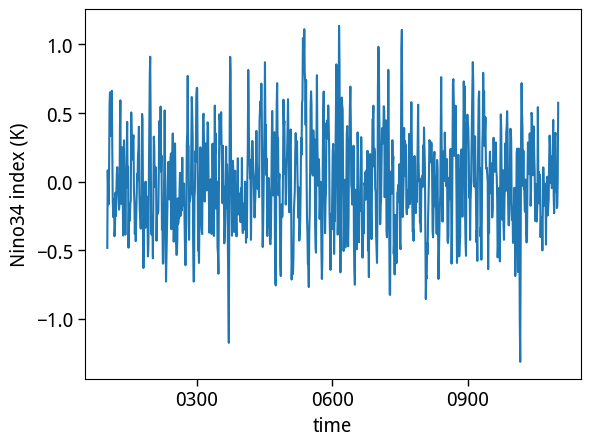

In [39]:
nino34_pic.rolling(time = 3, center=True).mean('time').plot()
plt.ylabel('Nino34 index (K)')

In [40]:
nino3_pic = funcs.calc_anom(ts_pic_loaded, ts_pic_loaded).sel(lat = slice(-5, 5), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon'))
nino4_pic = funcs.calc_anom(ts_pic_loaded, ts_pic_loaded).sel(lat = slice(-5, 5), lon = slice(160, -150+360)).weighted(weights_model).mean(('lat', 'lon'))

In [41]:
sst_grad_pic = (funcs.calc_anom(ts_pic_loaded, ts_pic_loaded).sel(lat=slice(-5,5), lon = slice(140, 170)).weighted(weights_model).mean(('lat', 'lon')) - funcs.calc_anom(ts_pic_loaded, ts_pic_loaded).sel(lat=slice(-5,5), lon = slice(190, 270)).weighted(weights_model).mean(('lat', 'lon')))
sst_grad_pic

<xarray.DataArray 'ts' (time: 2001)>
array([ 0.44843263, -0.50798935, -0.07014902, ...,         nan,
               nan,         nan])
Coordinates:
  * time     (time) object 0100-12-31 00:00:00 ... 2100-12-31 00:00:00
    model    (time) <U13 'ACCESS-ESM1-5' 'ACCESS-ESM1-5' ... 'ACCESS-ESM1-5'
    month    (time) int64 12 12 12 12 12 12 12 12 12 ... 12 12 12 12 12 12 12 12

In [42]:
nino34_trans = funcs.detrend_rolling_window(ts_trans.sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15)
print('done')
nino34_stable = funcs.detrend_rolling_window(ts_stable.sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15)
print('done')

done
done


In [43]:
# nino3_trans = funcs.detrend_rolling_window(ts_trans.sel(lat = slice(-5, 5), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15)
# nino3_stable = funcs.detrend_rolling_window(ts_stable.sel(lat = slice(-5, 5), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15)

In [44]:
# nino4_trans = funcs.detrend_rolling_window(ts_trans.sel(lat = slice(-5, 5), lon = slice(160, -150+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15)
# nino4_stable = funcs.detrend_rolling_window(ts_stable.sel(lat = slice(-5, 5), lon = slice(160, -150+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15)

In [45]:
nino34_mag_trans = rolling_window_std(nino34_trans, window_size=30).isel(time = slice(15, -15))
nino34_mag_stable = rolling_window_std(nino34_stable, window_size=30).isel(time = slice(15, -15))

In [46]:
nino34_mag_pic = rolling_window_std(funcs.detrend_separate_check(nino34_pic, period=15, dim='time'), window_size=30).isel(time = slice(15, -15))

In [47]:
# nino3_mag_trans = rolling_window_std(nino3_trans, window_size=30).isel(time = slice(15, -15))
# nino3_mag_stable = rolling_window_std(nino3_stable, window_size=30).isel(time = slice(15, -15))

In [48]:
# nino4_mag_trans = rolling_window_std(nino4_trans, window_size=30).isel(time = slice(15, -15))
# nino4_mag_stable = rolling_window_std(nino4_stable, window_size=30).isel(time = slice(15, -15))

Text(0, 0.5, 'ENSO magnitude (degC)')

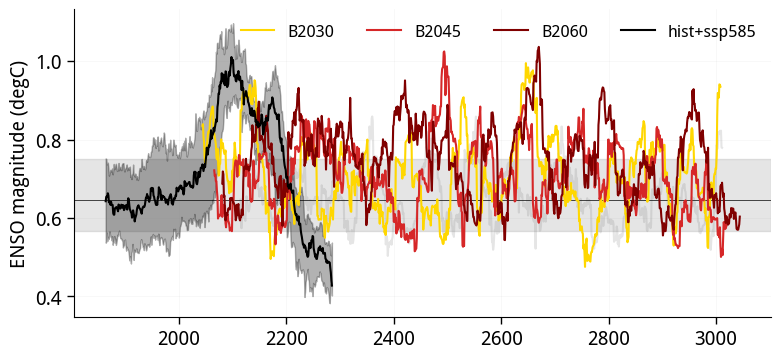

In [49]:
plt.figure(figsize=(9,4))

xdata = nino34_mag_pic.time.dt.year + 2000
plt.plot(xdata, nino34_mag_pic, color='tab:gray', alpha=0.2)
plt.axhspan(nino34_mag_pic.quantile(0.1, 'time'), nino34_mag_pic.quantile(0.9, 'time'), color='tab:gray', alpha=0.2)
plt.axhline(nino34_mag_pic.quantile(0.5, 'time'), color='k', lw=0.5)

plt.plot(nino34_mag_stable.time.dt.year, nino34_mag_stable.sel(model = 'B2030'), color='gold', lw=1.5, label='B2030')
# plt.axhline(nino34_mag_stable.sel(model='B2030').quantile(0.5, dim='time'), color='gold')

plt.plot(nino34_mag_stable.time.dt.year, nino34_mag_stable.sel(model = 'B2045'), color='tab:red', lw=1.5, label='B2045')
# plt.axhline(nino34_mag_stable.sel(model='B2045').quantile(0.5, dim='time'), color='tab:red')

plt.plot(nino34_mag_stable.time.dt.year, nino34_mag_stable.sel(model = 'B2060'), color='maroon', lw=1.5, label='B2060')
# plt.axhline(nino34_mag_stable.sel(model='B2060').quantile(0.5, dim='time'), color='maroon')

plt.plot(nino34_mag_trans.time.dt.year, nino34_mag_trans.quantile(0.5, 'model'), color='k', lw=1.5, label='hist+ssp585')
# plt.plot(nino34_mag_trans.time.dt.year, nino34_mag_trans.sel(model='ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp5 r10')
plt.fill_between(nino34_mag_trans.time.dt.year, nino34_mag_trans.quantile(0.1, 'model'), nino34_mag_trans.quantile(0.9, 'model'), color='k', alpha=0.3)
## plt.axhline(rolling_std_picontrol.quantile(0.1, dim='time'))
# # plt.axhline(rolling_std_picontrol.quantile(0.9, dim='time'))
# plt.ylim(0, 1.2)
# sns.despine(left=True, trim=True)
# plt.yticks([])
# # plt.minorticks_on()
# # plt.gca().tick_params(bottom=False, axis='x', which='minor')
plt.legend(frameon=False, fontsize=12, loc='upper right', ncol=4)
plot_decorator()
plt.ylabel('ENSO magnitude (degC)')
# plt.xlabel('Year')


In [50]:
def plot_dist_inset(ax, val, yval, color, dim=("time")):
    # Error bars (0.1, 0.5, 0.9 quantiles)
    q10 = val.quantile(0.1, dim=dim)
    q50 = val.quantile(0.5, dim=dim)
    q90 = val.quantile(0.9, dim=dim)
    
    ax.errorbar(
        x=q50, y=yval,
        xerr=[[q50 - q10], [q90 - q50]],
        fmt="o", color=color, mfc="white", mec=color,
        capsize=4, lw=2.0, ms=6, mew=1.2, zorder=5
    )
    

Text(0.5, 0, 'ENSO Magnitude (degC)')

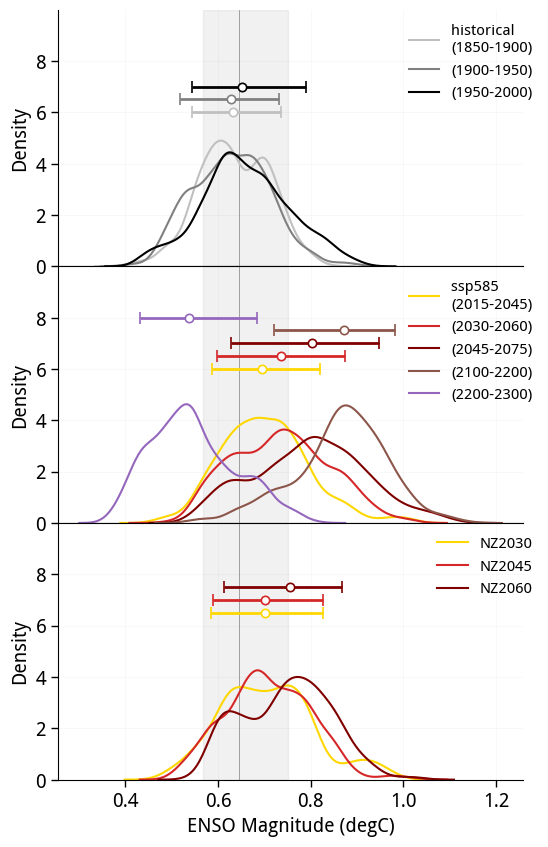

In [50]:
fig, axarr = plt.subplots(nrows=3, ncols=1, figsize=(6,10), constrained_layout=True, sharex=True, sharey=True)
axlist = axarr.flatten()


###
axlist[0].axvline(nino34_mag_pic.quantile(0.5, 'time'), color='tab:gray', lw=0.5)
axlist[0].axvspan(nino34_mag_pic.quantile(0.1, 'time'), nino34_mag_pic.quantile(0.9, 'time'), color='tab:gray', alpha=0.1)
sns.kdeplot(np.ravel(nino34_mag_trans.sel(time = slice('1850', '1900'))), color='silver', ax=axlist[0], label='historical \n(1850-1900)')
sns.kdeplot(np.ravel(nino34_mag_trans.sel(time = slice('1900', '1950'))), color='gray', ax=axlist[0], label='(1900-1950)')
sns.kdeplot(np.ravel(nino34_mag_trans.sel(time = slice('1950', '2000'))), color='k', ax=axlist[0], label='(1950-2000)')
# axlist[0].axvline(np.mean(np.ravel(nino34_mag_trans.sel(time = slice('1850', '1900')))), color='k', lw=1.0)
plot_dist_inset(axlist[0], nino34_mag_trans.sel(time = slice('1850', '1900')), 6, color='silver', dim=(("time", "model")))
plot_dist_inset(axlist[0], nino34_mag_trans.sel(time = slice('1900', '1950')), 6.5, color='gray', dim=(("time", "model")))
plot_dist_inset(axlist[0], nino34_mag_trans.sel(time = slice('1950', '2000')), 7, color='k', dim=(("time", "model")))

###
axlist[1].axvline(nino34_mag_pic.quantile(0.5, 'time'), color='tab:gray', lw=0.5)
axlist[1].axvspan(nino34_mag_pic.quantile(0.1, 'time'), nino34_mag_pic.quantile(0.9, 'time'), color='tab:gray', alpha=0.1)

sns.kdeplot(np.ravel(nino34_mag_trans.sel(time = slice('2015', '2045'))), color='gold', ax=axlist[1], label='ssp585 \n(2015-2045)')
plot_dist_inset(axlist[1], nino34_mag_trans.sel(time = slice('2015', '2045')), 6, color='gold', dim=(("time", "model")))
# axlist[1].axvline(np.mean(np.ravel(nino34_mag_trans.sel(time = slice('2015', '2045')))), color='gold', lw=1.0)

sns.kdeplot(np.ravel(nino34_mag_trans.sel(time = slice('2030', '2060'))), color='tab:red', ax=axlist[1], label='(2030-2060)')
plot_dist_inset(axlist[1], nino34_mag_trans.sel(time = slice('2030', '2060')), 6.5, color='tab:red', dim=(("time", "model")))
# axlist[1].axvline(np.mean(np.ravel(nino34_mag_trans.sel(time = slice('2030', '2060')))), color='tab:red', lw=1.0)

sns.kdeplot(np.ravel(nino34_mag_trans.sel(time = slice('2045', '2075'))), color='maroon', ax=axlist[1], label='(2045-2075)')
plot_dist_inset(axlist[1], nino34_mag_trans.sel(time = slice('2045', '2075')), 7.0, color='maroon', dim=(("time", "model")))
# axlist[1].axvline(np.mean(np.ravel(nino34_mag_trans.sel(time = slice('2045', '2075')))), color='maroon', lw=1.0)

sns.kdeplot(np.ravel(nino34_mag_trans.sel(time = slice('2100', '2200'))), color='tab:brown', ax=axlist[1], label='(2100-2200)')
plot_dist_inset(axlist[1], nino34_mag_trans.sel(time = slice('2100', '2200')), 7.5, color='tab:brown', dim=(("time", "model")))
# axlist[1].axvline(np.nanmean(np.ravel(nino34_mag_trans.sel(time = slice('2100', '2200')))), color='tab:brown', lw=1.0)

sns.kdeplot(np.ravel(nino34_mag_trans.sel(time = slice('2200', '2300'))), color='tab:purple', ax=axlist[1], label='(2200-2300)')
plot_dist_inset(axlist[1], nino34_mag_trans.sel(time = slice('2200', '2300')), 8.0, color='tab:purple', dim=(("time", "model")))
# axlist[1].axvline(np.nanmean(np.ravel(nino34_mag_trans.sel(time = slice('2200', '2300')))), color='tab:purple', lw=1.0)

###
axlist[2].axvline(nino34_mag_pic.quantile(0.5, 'time'), color='tab:gray', lw=0.5)
axlist[2].axvspan(nino34_mag_pic.quantile(0.1, 'time'), nino34_mag_pic.quantile(0.9, 'time'), color='tab:gray', alpha=0.1)
sns.kdeplot(nino34_mag_stable.sel(model='B2030'), color='gold', ax=axlist[2], label='NZ2030')
plot_dist_inset(axlist[2], nino34_mag_stable.sel(model = 'B2030'), 6.5, color='gold', dim=(("time")))
# axlist[2].axvline(nino34_mag_stable.sel(model = 'B2030').mean('time'), color='gold', lw=1.0)

sns.kdeplot(nino34_mag_stable.sel(model='B2045'), color='tab:red', ax=axlist[2], label='NZ2045')
plot_dist_inset(axlist[2], nino34_mag_stable.sel(model = 'B2045'), 7.0, color='tab:red', dim=(("time")))
# axlist[2].axvline(nino34_mag_stable.sel(model = 'B2045').mean('time'), color='tab:red', lw=1.0)

sns.kdeplot(nino34_mag_stable.sel(model='B2060'), color='maroon', ax=axlist[2], label='NZ2060')
plot_dist_inset(axlist[2], nino34_mag_stable.sel(model = 'B2060'), 7.5, color='maroon', dim=(("time")))
# axlist[2].axvline(nino34_mag_stable.sel(model = 'B2060').mean('time'), color='maroon', lw=1.0)

for ax in np.ravel(axlist):
#     # axlist[j].
#     pass
    ax.legend(frameon=False, fontsize=11, loc='upper right', bbox_to_anchor=(1.05, 1))
    ax.grid(color='gray', lw=0.4, alpha=0.1)
    # ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# sns.despine(trim=True, bottom=False)
# sns.despine()
# plt.xticks([])
plt.ylim(0, 10)
# plt.ylim(0, 0.9)
plt.gca().set_yticks(np.arange(0, 10, 2))
plt.subplots_adjust(wspace=0.0, hspace=0.0)
axlist[0].spines['top'].set_visible(False)
# plt.minorticks_on()
plt.xlabel('ENSO Magnitude (degC)')

In [51]:
sst_grad_trans = ts_trans.sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights_model).mean(('lat', 'lon')) - ts_trans.sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights_model).mean(('lat', 'lon'))
rolling_sst_grad_trans = (rolling_window_smoothing(sst_grad_trans, window_size=30)).isel(time = slice(15, -15))

sst_grad_stable = ts_stable.sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights_model).mean(('lat', 'lon')) - ts_stable.sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights_model).mean(('lat', 'lon'))
rolling_sst_grad_stable = (rolling_window_smoothing(sst_grad_stable, window_size=30)).isel(time = slice(15, -15))

In [52]:
rolling_sst_grad_pic = rolling_window_smoothing(sst_grad_pic, window_size=30).isel(time = slice(15, -15))

Text(0, 0.5, '$\\Delta$ ZTG (degC)')

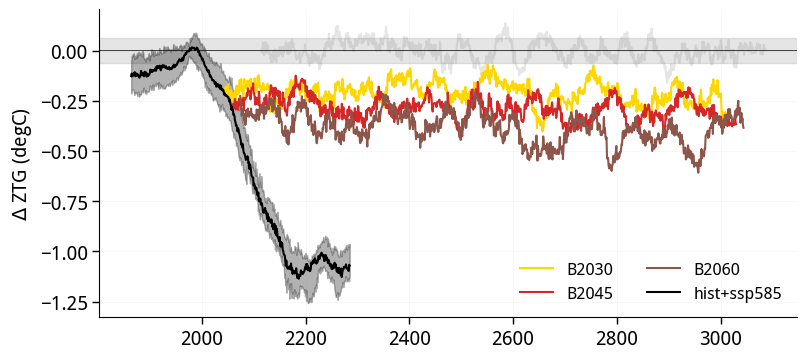

In [53]:
plt.figure(figsize=(9,4))

xdata = rolling_sst_grad_pic.time.dt.year + 2000
plt.plot(xdata, rolling_sst_grad_pic, color='tab:gray', alpha=0.2)
plt.axhspan(rolling_sst_grad_pic.quantile(0.1, 'time'), rolling_sst_grad_pic.quantile(0.9, 'time'), color='tab:gray', alpha=0.2)
plt.axhline(rolling_sst_grad_pic.quantile(0.5, 'time'), color='k', lw=0.5)

plt.plot(rolling_sst_grad_stable.time.dt.year, rolling_sst_grad_stable.sel(model = 'B2030'), color='gold', lw=1.5, label='B2030')
# plt.axhline(rolling_sst_grad_stable.sel(model='B2030').quantile(0.5, dim='time'), color='gold')

plt.plot(rolling_sst_grad_stable.time.dt.year, rolling_sst_grad_stable.sel(model = 'B2045'), color='tab:red', lw=1.5, label='B2045')
# plt.axhline(rolling_sst_grad_stable.sel(model='B2045').quantile(0.5, dim='time'), color='tab:red')

plt.plot(rolling_sst_grad_stable.time.dt.year, rolling_sst_grad_stable.sel(model = 'B2060'), color='tab:brown', lw=1.5, label='B2060')
# plt.axhline(rolling_sst_grad_stable.sel(model='B2060').quantile(0.5, dim='time'), color='tab:brown')

plt.plot(rolling_sst_grad_trans.time.dt.year, rolling_sst_grad_trans.quantile(0.5, 'model'), color='k', lw=1.5, label='hist+ssp585')
# plt.plot(rolling_sst_grad_trans.time.dt.year, rolling_sst_grad_trans.sel(model = 'ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp585 r10')
plt.fill_between(rolling_sst_grad_trans.time.dt.year, rolling_sst_grad_trans.quantile(0.1, 'model'), rolling_sst_grad_trans.quantile(0.9, 'model'), color='k', alpha=0.3)
# plt.axhline(rolling_std_picontrol.quantile(0.1, dim='time'))
# plt.axhline(rolling_std_picontrol.quantile(0.9, dim='time'))
# plt.ylim(-1.4, 0.5)
# sns.despine(left=True, trim=True)
# plt.yticks([])
# # plt.minorticks_on()
# # plt.gca().tick_params(bottom=False, axis='x', which='minor')
plt.legend(frameon=False, fontsize=12, loc='lower right', ncol=2)
# plt.axhline(0.0, color='k', lw=0.5)
plot_decorator()
plt.ylabel('$\Delta$ ZTG (degC)')
# plt.xlabel('Year')


Text(0.5, 0, '$\\Delta$ ZTG (degC)')

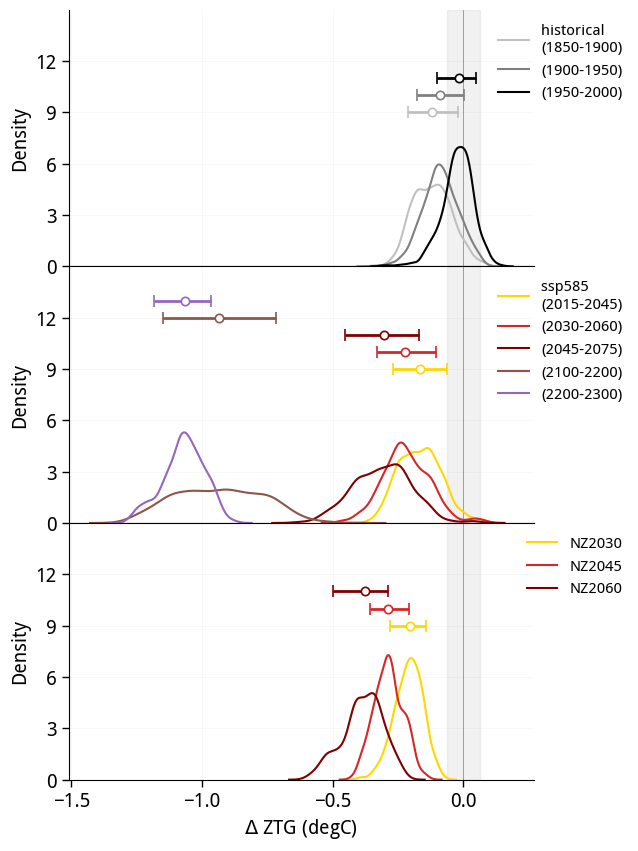

In [54]:
fig, axarr = plt.subplots(nrows=3, ncols=1, figsize=(6,10), constrained_layout=True, sharex=True, sharey=True)
axlist = axarr.flatten()


###
axlist[0].axvline(rolling_sst_grad_pic.quantile(0.5, 'time'), color='tab:gray', lw=0.5)
axlist[0].axvspan(rolling_sst_grad_pic.quantile(0.1, 'time'), rolling_sst_grad_pic.quantile(0.9, 'time'), color='tab:gray', alpha=0.1)
sns.kdeplot(np.ravel(rolling_sst_grad_trans.sel(time = slice('1850', '1900'))), color='silver', ax=axlist[0], label='historical \n(1850-1900)')
sns.kdeplot(np.ravel(rolling_sst_grad_trans.sel(time = slice('1900', '1950'))), color='gray', ax=axlist[0], label='(1900-1950)')
sns.kdeplot(np.ravel(rolling_sst_grad_trans.sel(time = slice('1950', '2000'))), color='k', ax=axlist[0], label='(1950-2000)')
# axlist[0].axvline(np.mean(np.ravel(rolling_sst_grad_trans.sel(time = slice('1850', '1900')))), color='k', lw=1.0)
plot_dist_inset(axlist[0], rolling_sst_grad_trans.sel(time = slice('1850', '1900')), 9, color='silver', dim=(("time", "model")))
plot_dist_inset(axlist[0], rolling_sst_grad_trans.sel(time = slice('1900', '1950')), 10, color='gray', dim=(("time", "model")))
plot_dist_inset(axlist[0], rolling_sst_grad_trans.sel(time = slice('1950', '2000')), 11, color='k', dim=(("time", "model")))

###
axlist[1].axvline(rolling_sst_grad_pic.quantile(0.5, 'time'), color='tab:gray', lw=0.5)
axlist[1].axvspan(rolling_sst_grad_pic.quantile(0.1, 'time'), rolling_sst_grad_pic.quantile(0.9, 'time'), color='tab:gray', alpha=0.1)

sns.kdeplot(np.ravel(rolling_sst_grad_trans.sel(time = slice('2015', '2045'))), color='gold', ax=axlist[1], label='ssp585 \n(2015-2045)')
plot_dist_inset(axlist[1], rolling_sst_grad_trans.sel(time = slice('2015', '2045')), 9, color='gold', dim=(("time", "model")))
# axlist[1].axvline(np.mean(np.ravel(rolling_sst_grad_trans.sel(time = slice('2015', '2045')))), color='gold', lw=1.0)

sns.kdeplot(np.ravel(rolling_sst_grad_trans.sel(time = slice('2030', '2060'))), color='tab:red', ax=axlist[1], label='(2030-2060)')
plot_dist_inset(axlist[1], rolling_sst_grad_trans.sel(time = slice('2030', '2060')), 10, color='tab:red', dim=(("time", "model")))
# axlist[1].axvline(np.mean(np.ravel(rolling_sst_grad_trans.sel(time = slice('2030', '2060')))), color='tab:red', lw=1.0)

sns.kdeplot(np.ravel(rolling_sst_grad_trans.sel(time = slice('2045', '2075'))), color='maroon', ax=axlist[1], label='(2045-2075)')
plot_dist_inset(axlist[1], rolling_sst_grad_trans.sel(time = slice('2045', '2075')), 11.0, color='maroon', dim=(("time", "model")))
# axlist[1].axvline(np.mean(np.ravel(rolling_sst_grad_trans.sel(time = slice('2045', '2075')))), color='maroon', lw=1.0)

sns.kdeplot(np.ravel(rolling_sst_grad_trans.sel(time = slice('2100', '2200'))), color='tab:brown', ax=axlist[1], label='(2100-2200)')
plot_dist_inset(axlist[1], rolling_sst_grad_trans.sel(time = slice('2100', '2200')), 12, color='tab:brown', dim=(("time", "model")))
# axlist[1].axvline(np.nanmean(np.ravel(rolling_sst_grad_trans.sel(time = slice('2100', '2200')))), color='tab:brown', lw=1.0)

sns.kdeplot(np.ravel(rolling_sst_grad_trans.sel(time = slice('2200', '2300'))), color='tab:purple', ax=axlist[1], label='(2200-2300)')
plot_dist_inset(axlist[1], rolling_sst_grad_trans.sel(time = slice('2200', '2300')), 13, color='tab:purple', dim=(("time", "model")))
# axlist[1].axvline(np.nanmean(np.ravel(rolling_sst_grad_trans.sel(time = slice('2200', '2300')))), color='tab:purple', lw=1.0)

###
axlist[2].axvline(rolling_sst_grad_pic.quantile(0.5, 'time'), color='tab:gray', lw=0.5)
axlist[2].axvspan(rolling_sst_grad_pic.quantile(0.1, 'time'), rolling_sst_grad_pic.quantile(0.9, 'time'), color='tab:gray', alpha=0.1)
sns.kdeplot(rolling_sst_grad_stable.sel(model='B2030'), color='gold', ax=axlist[2], label='NZ2030')
plot_dist_inset(axlist[2], rolling_sst_grad_stable.sel(model = 'B2030'), 9.0, color='gold', dim=(("time")))
# axlist[2].axvline(rolling_sst_grad_stable.sel(model = 'B2030').mean('time'), color='gold', lw=1.0)

sns.kdeplot(rolling_sst_grad_stable.sel(model='B2045'), color='tab:red', ax=axlist[2], label='NZ2045')
plot_dist_inset(axlist[2], rolling_sst_grad_stable.sel(model = 'B2045'), 10, color='tab:red', dim=(("time")))
# axlist[2].axvline(rolling_sst_grad_stable.sel(model = 'B2045').mean('time'), color='tab:red', lw=1.0)

sns.kdeplot(rolling_sst_grad_stable.sel(model='B2060'), color='maroon', ax=axlist[2], label='NZ2060')
plot_dist_inset(axlist[2], rolling_sst_grad_stable.sel(model = 'B2060'), 11, color='maroon', dim=(("time")))
# axlist[2].axvline(rolling_sst_grad_stable.sel(model = 'B2060').mean('time'), color='maroon', lw=1.0)

for ax in np.ravel(axlist):
#     # axlist[j].
#     pass
    ax.legend(frameon=False, fontsize=11, loc='upper right', bbox_to_anchor=(1.22, 1))
    ax.grid(color='gray', lw=0.4, alpha=0.1)
    # ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# sns.despine(trim=True, bottom=False)
# sns.despine()
# plt.xticks([])
plt.ylim(0, 15)
# plt.ylim(0, 0.9)
plt.gca().set_yticks(np.arange(0, 15, 3))
plt.subplots_adjust(wspace=0.0, hspace=0.0)
axlist[0].spines['top'].set_visible(False)
# plt.minorticks_on()
plt.xlabel('$\Delta$ ZTG (degC)')

## ENSO periodicity

In [53]:
from scipy.signal import welch
from scipy.stats import chi2
import numpy as np

def compute_psd(index, fs=1, nperseg=None, alpha=0.95):
    """
    Compute Welch PSD with AR(1) and white-noise significance,
    and normalized power.

    Returns
    -------
    periods : ndarray
        Periods corresponding to PSD.
    psd_norm : ndarray
        Normalized PSD.
    psd_ar1_norm : ndarray
        Normalized AR(1) significance spectrum.
    psd_wn_norm : float
        Normalized white-noise significance.
    """
    index = np.asarray(index).flatten()
    N = len(index)
    if nperseg is None:
        nperseg = N // 2

    f, Pxx = welch(index, fs=fs, window="hann", nperseg=nperseg, scaling="density")
    mask = f > 0
    f = f[mask]
    psd = Pxx[mask]
    periods = 1 / f

    # normalize PSD by variance
    psd_norm = psd / np.var(index)

    # AR(1 significance
    r1 = np.corrcoef(index[:-1], index[1:])[0,1]
    psd_ar1 = (1 - r1**2) / (1 + r1**2 - 2*r1*np.cos(2*np.pi*f/fs))
    psd_ar1 *= chi2.ppf(alpha, df=2) / 2
    psd_ar1_norm = psd_ar1  # already relative to variance=1

    # White-noise significance
    psd_wn_norm = chi2.ppf(alpha, df=2) / 2

    return periods, psd_norm, psd_ar1_norm, psd_wn_norm




def morlet_wavelet_spectrum_coi(x, dt=1, dj=0.25, s0=2, J=None):
    """
    Compute Morlet wavelet spectrum with COI and normalized power.
    """
    x = np.asarray(x).flatten()
    N = len(x)
    t = np.arange(N) * dt
    x = (x - np.mean(x)) / np.std(x)

    if J is None:
        J = int(np.log2(N*dt/s0) / dj)

    scales = s0 * 2 ** (np.arange(0, J+1) * dj)
    periods = scales.copy()

    # Fourier frequencies
    k = np.fft.fftfreq(N, d=dt) * 2*np.pi
    f = np.fft.fft(x)

    wave = np.zeros((len(scales), N), dtype=complex)

    for i, s in enumerate(scales):
        norm = (dt / s**0.5) * (np.pi**-0.25)
        # Morlet daughter in Fourier space
        expnt = -0.5 * (s * k - 6)**2
        daughter = norm * np.exp(expnt)
        wave[i, :] = np.fft.ifft(f * daughter)

    power = np.abs(wave)**2
    # power_norm = power / np.var(x)
    power_norm = power#/ np.max(power)

    # COI (1D, length N)
    coi = dt * np.minimum(np.arange(N), N - np.arange(N))
    coi = coi * 2**0.5

    return power_norm, scales, periods, t, coi



def generate_spectrum_ensemble(nino34_ds):
    # Define common grids
    common_periods = np.logspace(np.log10(0.5), np.log10(100), 200)  # PSD
    common_scales = np.logspace(np.log10(2), np.log10(50), 100)      # Morlet
    
    # Precompute max time length across all models
    max_time = max(len(nino34_ds.isel(model=i).time.dropna('time')) 
                   for i in range(nino34_ds.model.size))

    # Initialize lists
    psd_list, psd_ar1_list, psd_wn_list = [], [], []
    morlet_list = []
    coi_list = []

    for i in range(nino34_ds.model.size):
        # Extract 1D NumPy array of the time series
        ts = nino34_ds.isel(model=i).dropna('time').values.flatten()
        N = len(ts)
        if N < 5:
            continue  # skip very short series

        # ---- PSD ----
        periods, psd_norm, psd_ar1_norm, psd_wn_norm = compute_psd(ts)

        # Interpolate PSD to common periods
        psd_interp = np.interp(common_periods, periods[::-1], psd_norm[::-1])
        psd_ar1_interp = np.interp(common_periods, periods[::-1], psd_ar1_norm[::-1])
        psd_wn_interp = np.full_like(common_periods, psd_wn_norm)

        psd_list.append(psd_interp)
        psd_ar1_list.append(psd_ar1_interp)
        psd_wn_list.append(psd_wn_interp)

        # ---- Morlet ----
        power_norm, scales, periods_m, t, coi = morlet_wavelet_spectrum_coi(ts)

        # Interpolate Morlet power to common scales
        power_interp_scales = np.zeros((len(common_scales), power_norm.shape[1]))
        for j, s in enumerate(common_scales):
            idx = np.argmin(np.abs(scales - s))
            power_interp_scales[j, :] = power_norm[idx, :]

        # Interpolate Morlet power to common max_time
        x_old = np.linspace(0, 1, power_interp_scales.shape[1])
        x_new = np.linspace(0, 1, max_time)
        power_interp = np.zeros((len(common_scales), max_time))
        for j in range(len(common_scales)):
            power_interp[j, :] = np.interp(x_new, x_old, power_interp_scales[j, :])
        morlet_list.append(power_interp)

    # Interpolate COI to common max_time
    x_old = np.linspace(0, 1, len(coi))
    coi_interp = np.interp(x_new, x_old, coi)
    coi_list.append(coi_interp)

    psd_ensemble = np.array(psd_list)        # shape: (n_models, n_periods)
    psd_ar1_ensemble = np.array(psd_ar1_list)
    psd_wn_ensemble = np.array(psd_wn_list)

    morlet_ensemble = np.array(morlet_list)  # shape: (n_models, n_scales, n_time_max)
    coi_ensemble = np.array(coi_list)
    return psd_ensemble, psd_ar1_ensemble, psd_wn_ensemble, morlet_ensemble, coi_ensemble, common_periods, common_scales, max_time

    # PSD ensemble mean and spread
    # psd_mean_pic = np.mean(psd_ensemble, axis=0)
    # psd_std_pic = np.std(psd_ensembl, axis=0)

    # # Morlet ensemble mean (ignoring varying lengths for now)
    # morlet_mean_pic = np.mean(morlet_ensemble, axis=0)
    # morlet_std_pic = np.std(morlet_ensemble, axis=0)

    # # Average COI across ensemble (make sure you collected this earlier!)
    # coi_mean_pic = np.mean(np.vstack(coi_list), axis=0)

In [54]:
psd_ensemble_pic, psd_ar1_ensemble_pic, psd_wn_ensemble_pic, morlet_ensemble_pic, coi_ensemble_pic, common_periods, common_scales, max_time =  generate_spectrum_ensemble(additional_sampling_stabilisation_nomeans(nino34_pic, initiator=0, spacer=50))

Done


In [55]:
# PSD ensemble mean and spread
psd_mean_pic = np.mean(psd_ensemble_pic, axis=0)
psd_std_pic = np.std(psd_ensemble_pic, axis=0)

# Morlet ensemble mean (ignoring varying lengths for now)
morlet_mean_pic = np.mean(morlet_ensemble_pic, axis=0)
morlet_std_pic = np.std(morlet_ensemble_pic, axis=0)

# Average COI across ensemble (make sure you collected this earlier!)
coi_mean_pic = np.mean(np.vstack(coi_ensemble_pic), axis=0)

In [56]:
import matplotlib.ticker as ticker

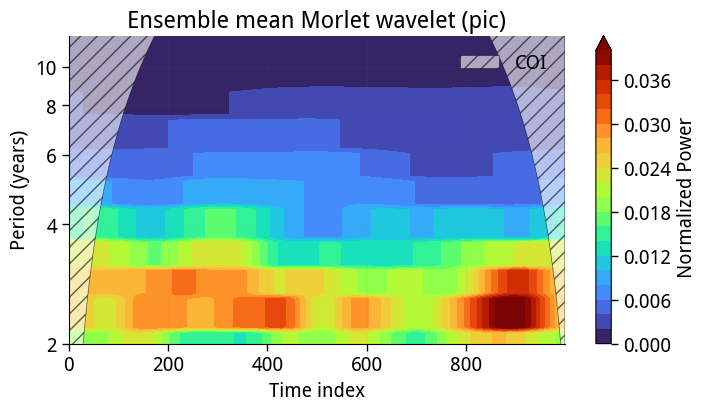

In [57]:
cutoff_shape = 1000
T, S = np.meshgrid(np.arange(morlet_mean_pic[:, :cutoff_shape].shape[1]), common_scales)

plt.figure(figsize=(8,4))
c = plt.contourf(T, S, morlet_mean_pic[:, :cutoff_shape], 100, cmap='turbo', vmin=0, vmax=0.04, levels= np.arange(0, 0.042, 0.002), extend='max')
plt.colorbar(c, label='Normalized Power')

# Log y-axis for scales/periods
plt.yscale('log')

# Add COI shading (cone below curve)
plt.fill_between(np.arange(cutoff_shape), coi_mean_pic[:cutoff_shape],
                 S.max(), color='white', alpha=0.6, hatch='//',
                 edgecolor='k', linewidth=0.5, label='COI')

plt.xlabel('Time index')
plt.ylabel('Period (years)')
plt.title('Ensemble mean Morlet wavelet (pic)')
plt.ylim(2, 12)
plt.legend(frameon=False)

ax = plt.gca()
# Use base=10, ticks at integer multiples
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2) * 0.1, numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2), numticks=10))

# Use plain numbers instead of 10^x
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

plot_decorator()

In [58]:
psd_ensemble_trans, psd_ar1_ensemble_trans, psd_wn_ensemble_trans, morlet_ensemble_trans, coi_ensemble_trans, common_periods, common_scales, max_time =  generate_spectrum_ensemble(nino34_trans.isel(time = slice(0, 250)))

In [59]:
# PSD ensemble mean and spread
psd_mean_trans = np.mean(psd_ensemble_trans, axis=0)
psd_std_trans = np.std(psd_ensemble_trans, axis=0)

# Morlet ensemble mean (ignoring varying lengths for now)
morlet_mean_trans = np.mean(morlet_ensemble_trans, axis=0)
morlet_std_trans = np.std(morlet_ensemble_trans, axis=0)

# Average COI across ensemble (make sure you collected this earlier!)
coi_mean_trans = np.mean(np.vstack(coi_ensemble_trans), axis=0)

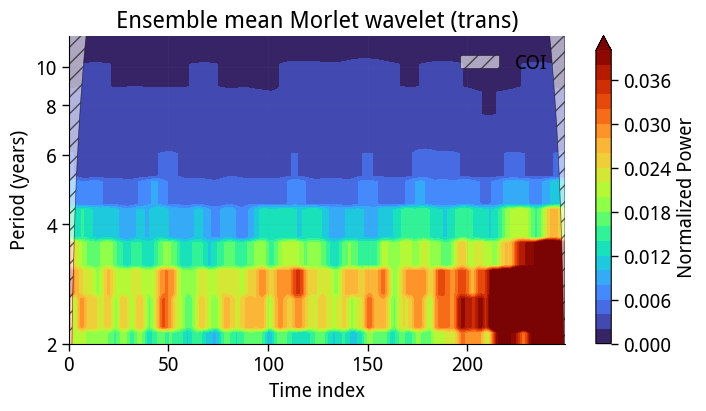

In [60]:
cutoff_shape = 250
T, S = np.meshgrid(np.arange(morlet_mean_trans[:, :cutoff_shape].shape[1]), common_scales)

plt.figure(figsize=(8,4))
c = plt.contourf(T, S, morlet_mean_trans[:, :cutoff_shape], 100, cmap='turbo', vmin=0, vmax=0.04, levels= np.arange(0, 0.042, 0.002), extend='max')
plt.colorbar(c, label='Normalized Power')

# Log y-axis for scales/periods
plt.yscale('log')

# Add COI shading (cone below curve)
plt.fill_between(np.arange(cutoff_shape), coi_mean_trans[:cutoff_shape],
                 S.max(), color='white', alpha=0.6, hatch='//',
                 edgecolor='k', linewidth=0.5, label='COI')

plt.xlabel('Time index')
plt.ylabel('Period (years)')
plt.title('Ensemble mean Morlet wavelet (trans)')
plt.ylim(2, 12)
plt.legend(frameon=False)

ax = plt.gca()
# Use base=10, ticks at integer multiples
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2) * 0.1, numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2), numticks=10))

# Use plain numbers instead of 10^x
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

plot_decorator()

In [85]:
psd_ensemble_stable, psd_ar1_ensemble_stable, psd_wn_ensemble_stable, morlet_ensemble_stable, coi_ensemble_stable, common_periods, common_scales, max_time =  generate_spectrum_ensemble(additional_sampling_stabilisation_nomeans(nino34_stable.sel(model = 'B2060'), initiator=0, spacer=50))

Done


In [86]:
# PSD ensemble mean and spread
psd_mean_stable = np.mean(psd_ensemble_stable, axis=0)
psd_std_stable = np.std(psd_ensemble_stable, axis=0)

# Morlet ensemble mean (ignoring varying lengths for now)
morlet_mean_stable = np.mean(morlet_ensemble_stable, axis=0)
morlet_std_stable = np.std(morlet_ensemble_stable, axis=0)

# Average COI across ensemble (make sure you collected this earlier!)
coi_mean_stable = np.mean(np.vstack(coi_ensemble_stable), axis=0)

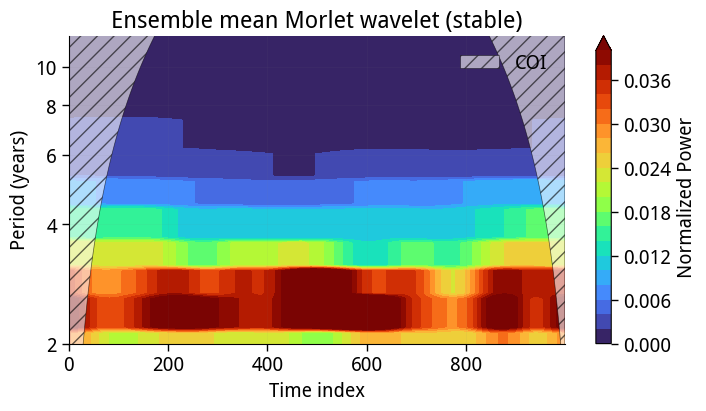

In [87]:
cutoff_shape = 1000
T, S = np.meshgrid(np.arange(morlet_mean_stable[:, :cutoff_shape].shape[1]), common_scales)

plt.figure(figsize=(8,4))
c = plt.contourf(T, S, morlet_mean_stable[:, :cutoff_shape], 100, cmap='turbo', vmin=0, vmax=0.04, levels= np.arange(0, 0.042, 0.002), extend='max')
plt.colorbar(c, label='Normalized Power')

# Log y-axis for scales/periods
plt.yscale('log')

# Add COI shading (cone below curve)
plt.fill_between(np.arange(cutoff_shape), coi_mean_stable[:cutoff_shape],
                 S.max(), color='white', alpha=0.6, hatch='//',
                 edgecolor='k', linewidth=0.5, label='COI')

plt.xlabel('Time index')
plt.ylabel('Period (years)')
plt.title('Ensemble mean Morlet wavelet (stable)')
plt.ylim(2, 12)
plt.legend(frameon=False)

ax = plt.gca()
# Use base=10, ticks at integer multiples
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2) * 0.1, numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2), numticks=10))

# Use plain numbers instead of 10^x
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

plot_decorator()

In [88]:
morlet_anomaly_trans = morlet_mean_trans - np.mean(morlet_mean_pic[:, :1000], axis=1).reshape(100, 1).repeat(250, 1)

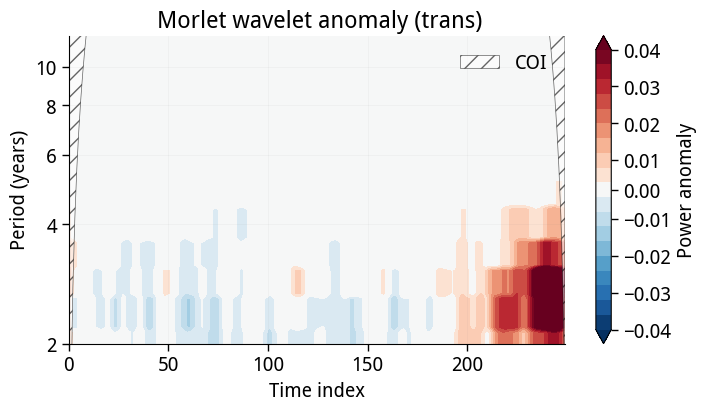

In [89]:
cutoff_shape = 250
T, S = np.meshgrid(np.arange(morlet_anomaly_trans[:, :cutoff_shape].shape[1]), common_scales)

plt.figure(figsize=(8,4))
c = plt.contourf(T, S, morlet_anomaly_trans[:, :cutoff_shape], 100, cmap='RdBu_r', vmin=-0.04, vmax=0.04, levels= np.concatenate((np.arange(-0.04, 0, 0.004), np.arange(0.004, 0.044, 0.004))), extend='both')
plt.colorbar(c, label='Power anomaly', ticks = np.arange(-0.04, 0.05, 0.01))

# Log y-axis for scales/periods
plt.yscale('log')

# Add COI shading (cone below curve)
plt.fill_between(np.arange(cutoff_shape), coi_mean_trans[:cutoff_shape],
                 S.max(), color='white', alpha=0.6, hatch='//',
                 edgecolor='k', linewidth=0.5, label='COI')

plt.xlabel('Time index')
plt.ylabel('Period (years)')
plt.title(' Morlet wavelet anomaly (trans)')
plt.ylim(2, 12)
plt.legend(frameon=False)

ax = plt.gca()
# Use base=10, ticks at integer multiples
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2) * 0.1, numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2), numticks=10))

# Use plain numbers instead of 10^x
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

plot_decorator()

In [90]:
morlet_anomaly_stable = morlet_mean_stable - np.mean(morlet_mean_pic[:, :1000], axis=1).reshape(100, 1).repeat(1000, 1)

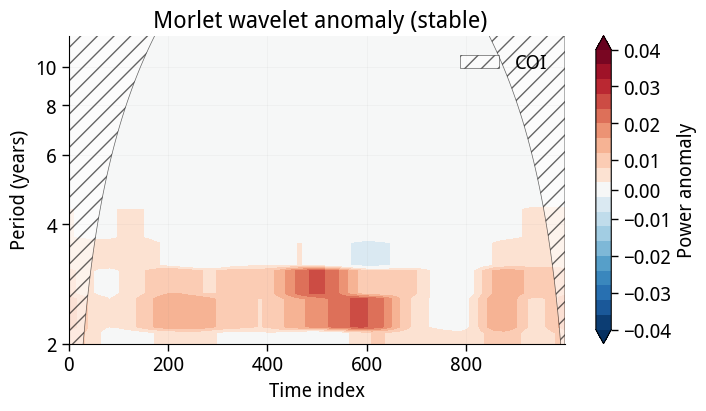

In [91]:
cutoff_shape = 1000
T, S = np.meshgrid(np.arange(morlet_anomaly_stable[:, :cutoff_shape].shape[1]), common_scales)

plt.figure(figsize=(8,4))
c = plt.contourf(T, S, morlet_anomaly_stable[:, :cutoff_shape], 100, cmap='RdBu_r', vmin=-0.04, vmax=0.04, levels= np.concatenate((np.arange(-0.04, 0, 0.004), np.arange(0.004, 0.044, 0.004))), extend='both')
plt.colorbar(c, label='Power anomaly', ticks = np.arange(-0.04, 0.05, 0.01))

# Log y-axis for scales/periods
plt.yscale('log')

# Add COI shading (cone below curve)
plt.fill_between(np.arange(cutoff_shape), coi_mean_stable[:cutoff_shape],
                 S.max(), color='white', alpha=0.6, hatch='//',
                 edgecolor='k', linewidth=0.5, label='COI')

plt.xlabel('Time index')
plt.ylabel('Period (years)')
plt.title(' Morlet wavelet anomaly (stable)')
plt.ylim(2, 12)
plt.legend(frameon=False)

ax = plt.gca()
# Use base=10, ticks at integer multiples
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2) * 0.1, numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2), numticks=10))

# Use plain numbers instead of 10^x
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

plot_decorator()

In [92]:
morlet_anomaly_stable1 = morlet_mean_stable - np.mean(morlet_mean_trans[:, :250], axis=1).reshape(100, 1).repeat(1000, 1)

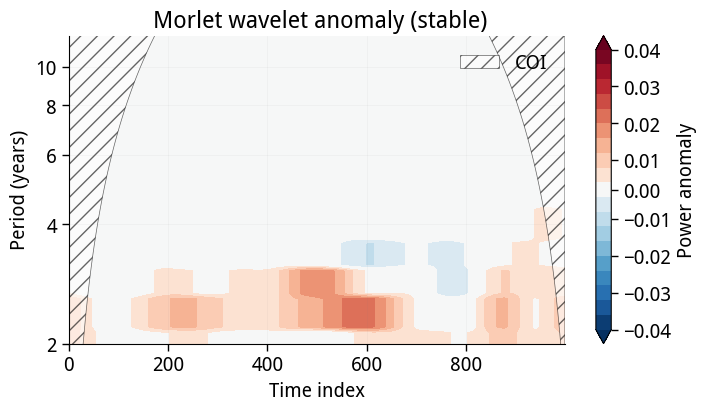

In [93]:
cutoff_shape = 1000
T, S = np.meshgrid(np.arange(morlet_anomaly_stable1[:, :cutoff_shape].shape[1]), common_scales)

plt.figure(figsize=(8,4))
c = plt.contourf(T, S, morlet_anomaly_stable1[:, :cutoff_shape], 100, cmap='RdBu_r', vmin=-0.04, vmax=0.04, levels= np.concatenate((np.arange(-0.04, 0, 0.004), np.arange(0.004, 0.044, 0.004))), extend='both')
plt.colorbar(c, label='Power anomaly', ticks = np.arange(-0.04, 0.05, 0.01))

# Log y-axis for scales/periods
plt.yscale('log')

# Add COI shading (cone below curve)
plt.fill_between(np.arange(cutoff_shape), coi_mean_stable[:cutoff_shape],
                 S.max(), color='white', alpha=0.6, hatch='//',
                 edgecolor='k', linewidth=0.5, label='COI')

plt.xlabel('Time index')
plt.ylabel('Period (years)')
plt.title(' Morlet wavelet anomaly (stable)')
plt.ylim(2, 12)
plt.legend(frameon=False)

ax = plt.gca()
# Use base=10, ticks at integer multiples
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2) * 0.1, numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2), numticks=10))

# Use plain numbers instead of 10^x
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

plot_decorator()

In [94]:
np.shape(morlet_ensemble_pic)

(20, 100, 1000)

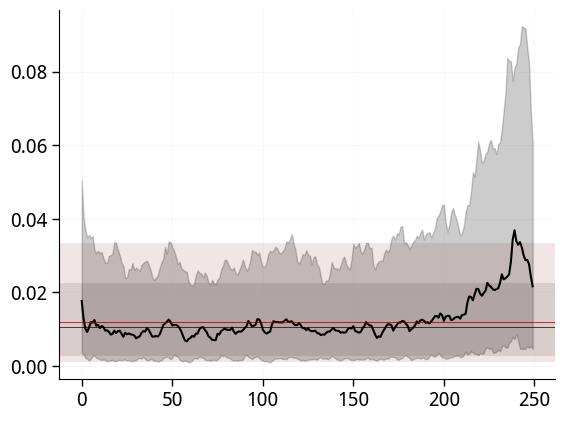

In [100]:
# plt.plot(np.arange(0, 1000, 1), np.quantile(morlet_ensemble_pic, 0.5, axis=0)[(common_scales >= 2) & (common_scales <= 7)].mean(axis=0))
# plt.fill_between(np.arange(0, 1000, 1), np.quantile(morlet_ensemble_pic, 0.1, axis=0)[(common_scales >= 2) & (common_scales <= 7)].mean(axis=0), np.quantile(morlet_ensemble_pic, 0.9, axis=0)[(common_scales >= 2) & (common_scales <= 7)].mean(axis=0), alpha=0.1)

plt.axhline(np.quantile(np.quantile(morlet_ensemble_pic, 0.5, axis=0)[(common_scales >= 2) & (common_scales <= 7)], 0.5), color='k', lw=0.5)
plt.axhspan(np.quantile(np.quantile(morlet_ensemble_pic, 0.5, axis=0)[(common_scales >= 2) & (common_scales <= 7)], 0.1), np.quantile(np.quantile(morlet_ensemble_pic, 0.5, axis=0)[(common_scales >= 2) & (common_scales <= 7)], 0.9), color='k', lw=0.0, alpha=0.1)

plt.plot(np.arange(0, 250, 1), np.quantile(morlet_ensemble_trans, 0.5, axis=0)[(common_scales >= 2) & (common_scales <= 7)].mean(axis=0), color='k')
plt.fill_between(np.arange(0, 250, 1), np.quantile(morlet_ensemble_trans, 0.1, axis=0)[(common_scales >= 2) & (common_scales <= 7)].mean(axis=0), np.quantile(morlet_ensemble_trans, 0.9, axis=0)[(common_scales >= 2) & (common_scales <= 7)].mean(axis=0), alpha=0.2, color='k')

# plt.plot(np.arange(0, 250, 1), np.quantile(morlet_ensemble_trans, 0.5, axis=0)[(common_scales > 3) & (common_scales <= 8)].mean(axis=0))
# plt.fill_between(np.arange(0, 250, 1), np.quantile(morlet_ensemble_trans, 0.1, axis=0)[(common_scales > 3) & (common_scales <= 8)].mean(axis=0), np.quantile(morlet_ensemble_trans, 0.9, axis=0)[(common_scales > 3) & (common_scales <= 8)].mean(axis=0), alpha=0.1)

# plt.plot(np.arange(0, 1000, 1), np.quantile(morlet_ensemble_stable, 0.5, axis=0)[(common_scales >= 2) & (common_scales <= 7)].mean(axis=0))
# plt.fill_between(np.arange(0, 1000, 1), np.quantile(morlet_ensemble_stable, 0.1, axis=0)[(common_scales >= 2) & (common_scales <= 7)].mean(axis=0), np.quantile(morlet_ensemble_stable, 0.9, axis=0)[(common_scales >= 2) & (common_scales <= 7)].mean(axis=0), alpha=0.1)

plt.axhline(np.quantile(np.quantile(morlet_ensemble_stable, 0.5, axis=0)[(common_scales >= 2) & (common_scales <= 7)], 0.5), color='maroon', lw=0.5)
plt.axhspan(np.quantile(np.quantile(morlet_ensemble_stable, 0.5, axis=0)[(common_scales >= 2) & (common_scales <= 7)], 0.1), np.quantile(np.quantile(morlet_ensemble_stable, 0.5, axis=0)[(common_scales >= 2) & (common_scales <= 7)], 0.9), color='maroon', lw=0.0, alpha=0.1)
plot_decorator()